In [1]:
import pandas as pd
df = pd.read_csv("esr_dataset_15k_final.csv")
print(df.isnull().sum().sum())
df.shape

0


(14999, 1030)

In [2]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from scipy.signal import savgol_filter

In [3]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from scipy.signal import savgol_filter

In [4]:
# Load dataset
data = pd.read_csv("esr_dataset_15k_final.csv", header=None)

# Split input and output
X = data.iloc[:, :-6].values
y = data.iloc[:, -6:].values

print("Dataset loaded")
print("X shape:", X.shape)
print("y shape:", y.shape)

Dataset loaded
X shape: (15000, 1024)
y shape: (15000, 6)


In [5]:
print(np.min(X), np.max(X))
print(np.min(y), np.max(y))

-1.0 1.0
0.177348927885167 11.9997964131536


In [ ]:
# # Reduce size (faster + better training)
# X = X[:, ::4]

# print("After downsampling:", X.shape)

After downsampling: (15000, 256)


In [6]:
# Apply Savitzky-Golay filter
for i in range(X.shape[0]):
    X[i] = savgol_filter(X[i], window_length=15, polyorder=3)

print("Smoothing done")

Smoothing done


In [7]:
for i in range(X.shape[0]):
    X[i] = X[i] / np.max(np.abs(X[i]))

print("Normalization done")

Normalization done


In [ ]:
# # Add small noise
# X += np.random.normal(0, 0.01, X.shape)

# print("Augmentation done")

Augmentation done


In [8]:
# IMPORTANT: start from original X (before stacking)

# First derivative
X_diff1 = np.gradient(X, axis=1)

# Second derivative
# X_diff2 = np.gradient(X_diff1, axis=1)

# # Stack channels (ONLY ONCE)
# X = np.stack([X, X_diff1, 2*X_diff2], axis=2)

print("Multi-channel shape:", X.shape)

Multi-channel shape: (15000, 1024)


In [9]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=15
)

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)

Train shape: (12000, 1024)
Test shape: (3000, 1024)


In [12]:
scaler = StandardScaler()

# reshape for scaler
X_train_2d = X_train.reshape(X_train.shape[0], -1)
X_test_2d = X_test.reshape(X_test.shape[0], -1)

X_train_2d = scaler.fit_transform(X_train_2d)
X_test_2d = scaler.transform(X_test_2d)

# reshape back
X_train = X_train_2d.reshape(X_train.shape)
X_test = X_test_2d.reshape(X_test.shape)

print("Scaling done")

Scaling done


In [10]:
y_train_scaled = y_train.copy()
y_test_scaled = y_test.copy()

# Physics-aware scaling
y_train_scaled[:,0:2] /= 2.0      # g
y_train_scaled[:,2:4] /= 0.5      # linewidth
y_train_scaled[:,4:6] /= 12.0     # hyperfine

y_test_scaled[:,0:2] /= 2.0
y_test_scaled[:,2:4] /= 0.5
y_test_scaled[:,4:6] /= 12.0

print("Output scaling done")

Output scaling done


In [16]:
print("Final X_train shape:", X_train.shape)
print("Final y_train shape:", y_train_scaled.shape)

Final X_train shape: (12000, 1024)
Final y_train shape: (12000, 6)


In [11]:
import tensorflow as tf
from tensorflow.keras import layers, models

In [13]:
def residual_block(x, filters):

    shortcut = x

    x = layers.Conv1D(filters, 3, padding='same', activation='relu')(x)
    x = layers.BatchNormalization()(x)

    x = layers.Conv1D(filters, 3, padding='same')(x)
    x = layers.BatchNormalization()(x)

    # Match dimensions if needed
    if shortcut.shape[-1] != filters:
        shortcut = layers.Conv1D(filters, 1, padding='same')(shortcut)

    x = layers.Add()([x, shortcut])
    x = layers.Activation('relu')(x)

    return x

In [14]:
def attention_block(x):

    attn = layers.Dense(x.shape[-1], activation='softmax')(x)
    x = layers.Multiply()([x, attn])

    return x

In [17]:
X_train = X_train[..., np.newaxis]

inputs = tf.keras.Input(shape=(X_train.shape[1], X_train.shape[2]))

x = layers.Conv1D(32, 5, padding='same', activation='relu')(inputs)

# Residual blocks
x = residual_block(x, 32)
x = layers.MaxPooling1D(2)(x)

x = residual_block(x, 64)
x = layers.MaxPooling1D(2)(x)

x = residual_block(x, 128)

# Attention
x = attention_block(x)

# Global pooling
x = layers.GlobalAveragePooling1D()(x)

# Dense layers
x = layers.Dense(256, activation='relu')(x)
x = layers.Dropout(0.3)(x)

x = layers.Dense(64, activation='relu')(x)

outputs = layers.Dense(6)(x)

model = models.Model(inputs, outputs)

model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 1024, 1)   │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d (Conv1D)     │ (None, 1024, 32)  │        192 │ input_layer[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_1 (Conv1D)   │ (None, 1024, 32)  │      3,104 │ conv1d[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 1024, 32)  │        128 │ conv1d_1[0][0]    │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_2 (Conv1D)   │ (None, 1024, 32)  │      3,104 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 1024, 32)  │        128 │ conv1d_2[0][0]    │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 1024, 32)  │          0 │ batch_normalizat… │
│                     │                   │            │ conv1d[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation          │ (None, 1024, 32)  │          0 │ add[0][0]         │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling1d       │ (None, 512, 32)   │          0 │ activation[0][0]  │
│ (MaxPooling1D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_3 (Conv1D)   │ (None, 512, 64)   │      6,208 │ max_pooling1d[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 512, 64)   │        256 │ conv1d_3[0][0]    │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_4 (Conv1D)   │ (None, 512, 64)   │     12,352 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 512, 64)   │        256 │ conv1d_4[0][0]    │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_5 (Conv1D)   │ (None, 512, 64)   │      2,112 │ max_pooling1d[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_1 (Add)         │ (None, 512, 64)   │          0 │ batch_normalizat… │
│                     │                   │            │ conv1d_5[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_1        │ (None, 512, 64)   │          0 │ add_1[0][0]       │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling1d_1     │ (None, 256, 64)   │          0 │ activation_1[0][… │
│ (MaxPooling1D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_6 (Conv1D)   │ (None, 256, 128)  │     24,704 │ max_pooling1d_1[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 256, 128)  │        512 │ conv1d_6[0][0]    │
│ (BatchNormalizatio… │                   │            │                 

 Total params: 177,542 (693.52 KB)

 Trainable params: 176,646 (690.02 KB)

 Non-trainable params: 896 (3.50 KB)

In [18]:
def custom_loss(y_true, y_pred):

    weights = tf.constant([1.0,1.0,2.0,2.0,6.0,6.0])

    abs_error = tf.abs(y_true - y_pred)
    rel_error = abs_error / (tf.abs(y_true) + 1e-6)

    loss = weights * (0.5*abs_error + 0.5*rel_error)

    return tf.reduce_mean(loss)

In [28]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.00003),
    loss=custom_loss,
    metrics=['mae']
)

In [20]:
callbacks = [
    tf.keras.callbacks.EarlyStopping(patience=10, restore_best_weights=True),
    tf.keras.callbacks.ReduceLROnPlateau(patience=5)
]

In [29]:
history = model.fit(
    X_train,
    y_train_scaled,
    epochs=100,
    batch_size=32,
    validation_split=0.1,
    callbacks=callbacks
)

Epoch 1/100
338/338 ━━━━━━━━━━━━━━━━━━━━ 29s 66ms/step - loss: 0.2208 - mae: 0.0366 - val_loss: 0.8558 - val_mae: 0.2563 - learning_rate: 3.0000e-05
Epoch 2/100
338/338 ━━━━━━━━━━━━━━━━━━━━ 23s 67ms/step - loss: 0.2204 - mae: 0.0365 - val_loss: 0.2445 - val_mae: 0.0476 - learning_rate: 3.0000e-05
Epoch 3/100
338/338 ━━━━━━━━━━━━━━━━━━━━ 21s 62ms/step - loss: 0.2206 - mae: 0.0366 - val_loss: 0.2410 - val_mae: 0.0464 - learning_rate: 3.0000e-05
Epoch 4/100
338/338 ━━━━━━━━━━━━━━━━━━━━ 22s 65ms/step - loss: 0.2203 - mae: 0.0364 - val_loss: 4.3958 - val_mae: 1.7928 - learning_rate: 3.0000e-05
Epoch 5/100
338/338 ━━━━━━━━━━━━━━━━━━━━ 23s 69ms/step - loss: 0.2200 - mae: 0.0364 - val_loss: 0.2979 - val_mae: 0.0676 - learning_rate: 3.0000e-05
Epoch 6/100
338/338 ━━━━━━━━━━━━━━━━━━━━ 23s 69ms/step - loss: 0.2196 - mae: 0.0363 - val_loss: 0.6114 - val_mae: 0.1601 - learning_rate: 3.0000e-06
Epoch 7/100
338/338 ━━━━━━━━━━━━━━━━━━━━ 23s 68ms/step - loss: 0.2191 - mae: 0.0362 - val_loss: 0.2088 - v

In [30]:
pred_scaled = model.predict(X_test)

94/94 ━━━━━━━━━━━━━━━━━━━━ 2s 19ms/step


In [31]:
pred = pred_scaled.copy()

# Reverse scaling
pred[:,0:2] *= 2.0      # g
pred[:,2:4] *= 0.5      # linewidth
pred[:,4:6] *= 12.0     # hyperfine

y_true = y_test.copy()

In [25]:
pred_scaled = model.predict(X_test)

94/94 ━━━━━━━━━━━━━━━━━━━━ 2s 23ms/step


In [32]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

overall_mae = mean_absolute_error(y_true, pred)
overall_mse = mean_squared_error(y_true, pred)

print("OVERALL PERFORMANCE")
print("MAE:", round(overall_mae,4))
print("MSE:", round(overall_mse,4))

OVERALL PERFORMANCE
MAE: 0.3548
MSE: 0.6737


In [33]:
names = ["g1","g2","lw1","lw2","A1","A2"]

print("\nPARAMETER-WISE ERRORS\n")

for i, name in enumerate(names):

    mae = mean_absolute_error(y_true[:,i], pred[:,i])
    mse = mean_squared_error(y_true[:,i], pred[:,i])
    rmse = np.sqrt(mse)

    print(f"{name}:")
    print(f"  MAE  = {mae:.4f}")
    print(f"  RMSE = {rmse:.4f}")
    print(f"  MSE  = {mse:.4f}\n")


PARAMETER-WISE ERRORS

g1:
  MAE  = 0.0036
  RMSE = 0.0046
  MSE  = 0.0000

g2:
  MAE  = 0.0030
  RMSE = 0.0038
  MSE  = 0.0000

lw1:
  MAE  = 0.0071
  RMSE = 0.0090
  MSE  = 0.0001

lw2:
  MAE  = 0.0074
  RMSE = 0.0095
  MSE  = 0.0001

A1:
  MAE  = 1.0664
  RMSE = 1.4310
  MSE  = 2.0477

A2:
  MAE  = 1.0411
  RMSE = 1.4121
  MSE  = 1.9941



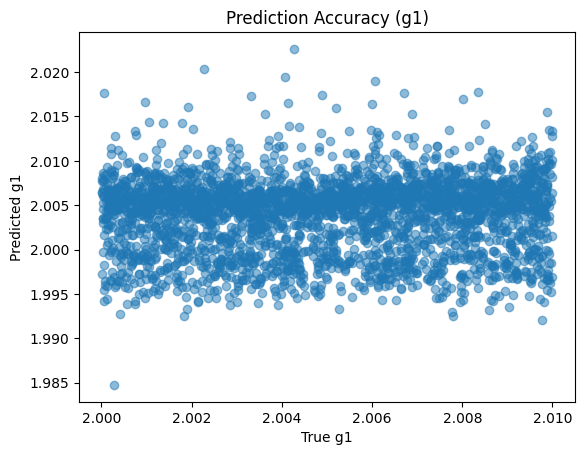

In [31]:
import matplotlib.pyplot as plt

plt.scatter(y_true[:,0], pred[:,0], alpha=0.5)
plt.xlabel("True g1")
plt.ylabel("Predicted g1")
plt.title("Prediction Accuracy (g1)")
plt.show()